<a href="https://colab.research.google.com/github/leonnmarcoo/CCDEPLRL_EXERCISES_COM232/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1: Mount Google Drive**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Step 2: Set Dataset Path**

In [ ]:
dataset_path = "/content/drive/MyDrive/Uni Life/Junior/3rd Term/Deep Learning/Project/Dataset"

## **Step 3: Import Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

## **Step 4: Prepare Image Dataset**

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## **Step 5: Load Training Dataset**

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 24 images belonging to 3 classes.


## **Step 6: Load Validation Dataset**

In [ ]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 6 images belonging to 3 classes.


## **Step 7: Build Simple CNN**

In [ ]:
model = models.Sequential()

model.add(layers. Conv2D(32, (3,3),
                         activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3),
activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Step 8: Compile Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 9: Train Model**

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3333 - loss: 1.1103 - val_accuracy: 0.3333 - val_loss: 2.1634
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4583 - loss: 2.0483 - val_accuracy: 0.3333 - val_loss: 1.0973
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4167 - loss: 0.9972 - val_accuracy: 0.3333 - val_loss: 1.5345
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.4572 - val_accuracy: 0.5000 - val_loss: 1.2785
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 1.1199 - val_accuracy: 0.6667 - val_loss: 1.0684
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7083 - loss: 0.8948 - val_accuracy: 0.3333 - val_loss: 0.9890
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 0.7999 - val_accuracy: 0.5000 - val_loss: 0.9775
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7500 - loss: 0.7315 - val_accuracy: 0.8333 - val_loss: 0.9010
Epoch 9/10
1/1 ━

## **Step 10: Evaluate Model**

In [ ]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8333 - loss: 0.7975
Validation Accuracy: 0.8333333134651184


## **Step 11: Plot Accuracy**

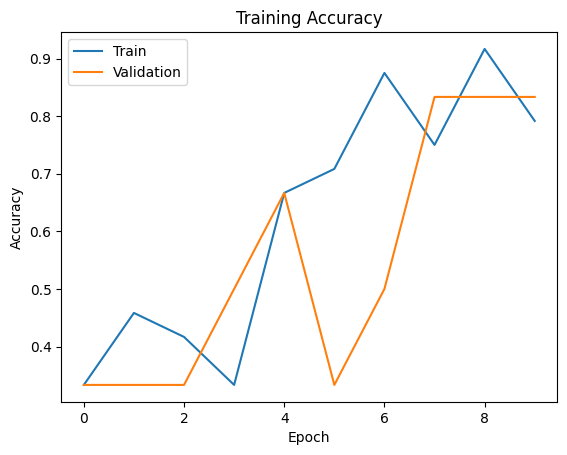

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

## **Step 12: Save Model**

In [ ]:
model.save("cnn_classifier.h5")

In [ ]:
from google.colab import files
files. download("cnn_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Step 13: Deploy in Streamlit**